# Aggregate Functions :

### Notes:
```
AGGREGATE FUNCTIONS : Performs a calculation on a set of values across multiple rows and returns a single summary value
Fucntions: COUNT(), SUM(), MIN(), MAX(), AVG()
1. Takes input as multiple rows or a set of values and out in single row or a single value
2. Often used by GROUP BY, HAVING, ORDER BY clause
```

### Challenges

#### Find the following 
```
1. total number of orders, 
2. total sales of all orders
3. average sales of all orders
4. highest sale of all orders
5. lowest sales of all orders
6. categorised by customer id
```

In [32]:
%%sql
use MyDatabase;
select customer_id, count(*) as `Total Sales Count`,
    sum(sales) as `Total Sales`,
    round(avg(sales), 1) as `AVG Sales`,
    max(sales) as `Highest Sale Value`,
    min(sales) as `Lowest Sale Value`    
from orders group by customer_id;

Running query in 'mysql+pymysql://'

4 rows affected.

customer_id,Total Sales Count,Total Sales,AVG Sales,Highest Sale Value,Lowest Sale Value
1,1,35,35.0,35,35
2,1,15,15.0,15,15
3,1,20,20.0,20,20
6,1,10,10.0,10,10


#### Find the following 
```
1. total number of customers, 
2. total score of all customers
3. average score of all customers
4. highest score of all customers
5. lowest score of all customers
6. categorised by country
```

In [40]:
%%sql
select country, count(*) as `Total Number of Customers`,
    sum(score) as `Total Score`,
    round(avg(ifnull(score, 0))) as `AVG Score`,
    max(score) as `Highest Score`,
    min(score) as `Lowest Score`
from customers
group by country;

Running query in 'mysql+pymysql://'

3 rows affected.

country,Total Number of Customers,Total Score,AVG Score,Highest Score,Lowest Score
Germany,2,850,425,500,350
USA,2,900,450,900,0
UK,1,750,750,750,750


# Window basics : 

### Notes:
```
WINDOW FUNCTIONS : Perform calculations (e.g. aggregation) on specific subset of data, without losing the level of details of rows
Functions : 
    AGGREGATE       : COUNT(expr), SUM(expr), AVG(expr), MIN(expr), MAX(expr)
    ROWS            : OVER(), OVER(ORDER/PARTITION BY columnName)
    RANK            : ROW_NUMBER(), RANK(), DENSE_RANK(), CUME_DIST(), PERCENT_RANK(), NTILE(n)
    VALUE ANALYTICS : LEAD(expr, offset, default), LAG(expr, offset, default), FIRST_VALUE(expr)
```

### Challenges:

#### Find the following from SALESDB:
```
1. Total sales
2. Total sales by each product
3. Total sales by each product but also provide details such as orderid and orderdate
```

In [55]:
%%sql
use salesdb;
select orderid,
    orderdate,
    productid,
    sum(sales) OVER(PARTITION BY productid) as `Total Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,Total Sales
1,2025-01-01,101,140
3,2025-01-10,101,140
8,2025-02-18,101,140
9,2025-03-10,101,140
2,2025-01-05,102,105
7,2025-02-15,102,105
10,2025-03-15,102,105
5,2025-02-01,104,75
6,2025-02-05,104,75
4,2025-01-20,105,60


### PARTITION BY : Divide the entire results into partitions or category

In [103]:
%%sql
use salesdb;
select product,
    monthname(o.orderdate) as Month,
    sales
from products as p
    left join orders as o on p.productid = o.productid
ORDER BY case
        when o.orderdate is null then 1
        else 0
    end ASC,
    month(o.orderdate) ASC;

Running query in 'mysql+pymysql://'

11 rows affected.

product,Month,sales
Bottle,January,10
Bottle,January,20
Tire,January,15
Gloves,January,60
Bottle,February,90
Tire,February,30
Caps,February,25
Caps,February,50
Bottle,March,20
Tire,March,60


#### CHALLENGE : 

##### Without Partition BY : 

Find the total sales across all orders, additionally provide details such as order id and order date

In [109]:
%%sql
select orderid,
    productid,
    orderdate,
    sum(sales) over() as `Total Sales`
from orders
order by productid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,orderdate,Total Sales
1,101,2025-01-01,380
3,101,2025-01-10,380
8,101,2025-02-18,380
9,101,2025-03-10,380
2,102,2025-01-05,380
7,102,2025-02-15,380
10,102,2025-03-15,380
5,104,2025-02-01,380
6,104,2025-02-05,380
4,105,2025-01-20,380


##### With Partition BY (Single Column): 

Find the total sales for each products, additionally provide details such as order id and order date

In [121]:
%%sql
select orderid,
    orderdate,
    productid, 
    sales,
    sum(sales) over(partition by productid) as `Total Sales By Product`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,sales,Total Sales By Product
1,2025-01-01,101,10,140
3,2025-01-10,101,20,140
8,2025-02-18,101,90,140
9,2025-03-10,101,20,140
2,2025-01-05,102,15,105
7,2025-02-15,102,30,105
10,2025-03-15,102,60,105
5,2025-02-01,104,25,75
6,2025-02-05,104,50,75
4,2025-01-20,105,60,60


Find the total sales for across all orders and for each products, additionally provide details such as order id and order date

In [120]:
%%sql
select orderid,
    orderdate,
    productid, 
    sales,
    sum(sales) over(partition by productid) as `Total Sales By Product`,
    sum(sales) over() as `Total Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,sales,Total Sales By Product,Total Sales
1,2025-01-01,101,10,140,380
3,2025-01-10,101,20,140,380
8,2025-02-18,101,90,140,380
9,2025-03-10,101,20,140,380
2,2025-01-05,102,15,105,380
7,2025-02-15,102,30,105,380
10,2025-03-15,102,60,105,380
5,2025-02-01,104,25,75,380
6,2025-02-05,104,50,75,380
4,2025-01-20,105,60,60,380


##### With Partition BY (Multi Column): 

```
Find the total sales 
                for across all orders and 
                for each products and 
                each combinations of product and order status,
        additionally provide details such as order id and order date
```

In [129]:
%%sql
select orderid,
    orderdate,
    productid,
    orderstatus,
    sales,
    sum(sales) over() as `Total Sales`,
    sum(sales) over(partition by productid) as `Total Sales By Product`,
    sum(sales) over(partition by productid, orderstatus) as `Total Sales By Product and Status`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,orderstatus,sales,Total Sales,Total Sales By Product,Total Sales By Product and Status
1,2025-01-01,101,Delivered,10,380,140,30
3,2025-01-10,101,Delivered,20,380,140,30
8,2025-02-18,101,Shipped,90,380,140,110
9,2025-03-10,101,Shipped,20,380,140,110
7,2025-02-15,102,Delivered,30,380,105,30
2,2025-01-05,102,Shipped,15,380,105,75
10,2025-03-15,102,Shipped,60,380,105,75
5,2025-02-01,104,Delivered,25,380,75,75
6,2025-02-05,104,Delivered,50,380,75,75
4,2025-01-20,105,Shipped,60,380,60,60


### ORDER BY : Use to sorth data within a window in eith ASC or DESC

##### Challenges :

Do the following from orders table:
1. Categorise by Month
2. RANK and Order by sales from highest to lowest
3. Additionally provide details such as Order id, product id, order date in format of 21st, Jun 2026

In [154]:
%%sql
select orderid,
    date_format(orderdate, '%D, %b %Y') as OrderDate,
    productid,
    Monthname(orderdate) as Month,
    Sales,
    RANK() over(
        partition by month(orderdate)
        order by sales desc
    ) as `Rank By Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,OrderDate,productid,Month,Sales,Rank By Sales
4,"20th, Jan 2025",105,January,60,1
3,"10th, Jan 2025",101,January,20,2
2,"5th, Jan 2025",102,January,15,3
1,"1st, Jan 2025",101,January,10,4
8,"18th, Feb 2025",101,February,90,1
6,"5th, Feb 2025",104,February,50,2
7,"15th, Feb 2025",102,February,30,3
5,"1st, Feb 2025",104,February,25,4
10,"15th, Mar 2025",102,March,60,1
9,"10th, Mar 2025",101,March,20,2


### FRAME or WINDOW FRAME : Use to define a subset of rows in each window that is relevent for calculation
```
And if in OVER() if order by is used then a default FRAME is always used as 'UNBOUNDED PRECEEDING' or 'ROWS BETWEEN CURRENT ROW AND UNBOUNDED PRECEEDING'
```

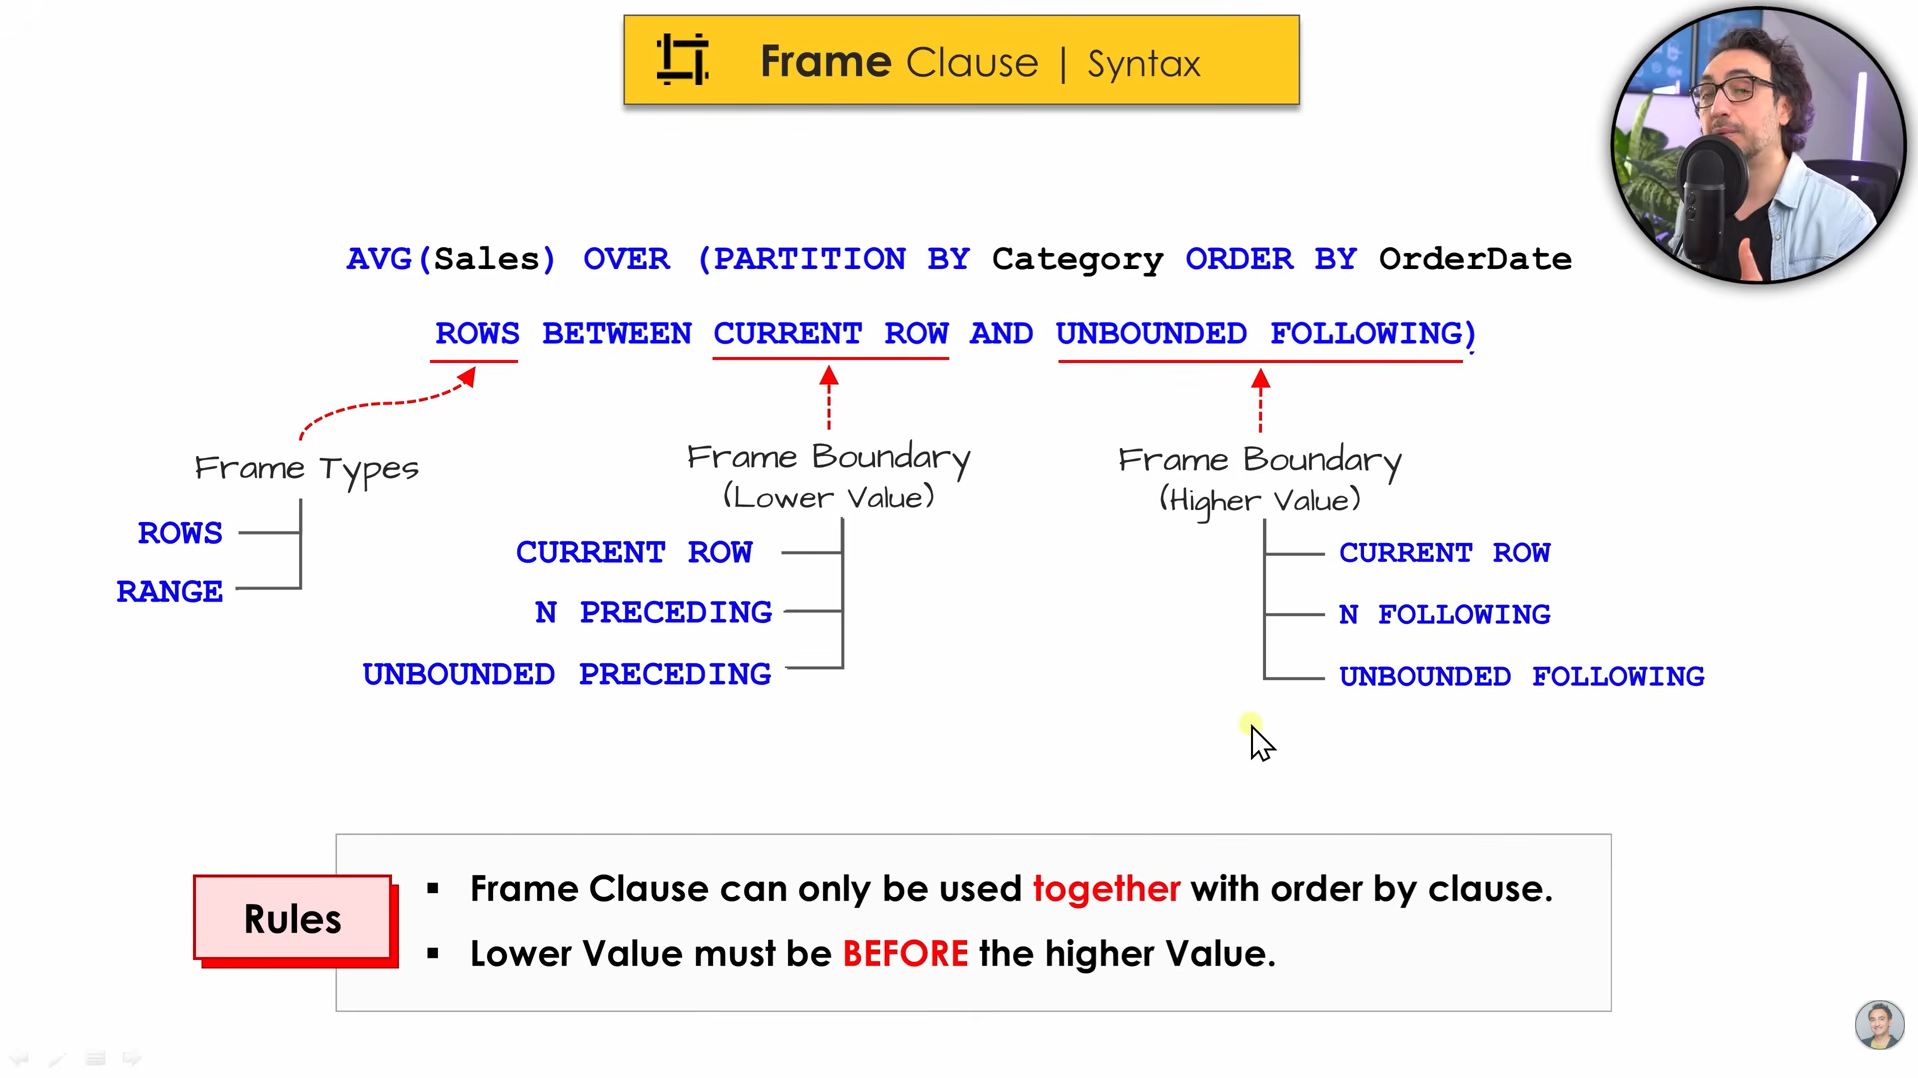

#### Challenges :

In [167]:
%%sql
select orderid,
    productid,
    monthname(orderdate) as `Month`,
    orderstatus,
    sales,
    sum(sales) over(
        partition by month(orderdate), orderstatus
        order by month(orderdate), orderstatus
        rows between current row and 2 following
    ) as `Total Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,Month,orderstatus,sales,Total Sales
1,101,January,Delivered,10,30
3,101,January,Delivered,20,20
2,102,January,Shipped,15,75
4,105,January,Shipped,60,60
5,104,February,Delivered,25,105
6,104,February,Delivered,50,80
7,102,February,Delivered,30,30
8,101,February,Shipped,90,90
9,101,March,Shipped,20,80
10,102,March,Shipped,60,60


### 4x RULES : 

#### RULES : 
1. WINDOW FUNCTION can be used only in select and order by clause.
2. WINDOW FUNCTION can not be used to filter the data.
3. Nesting of WINDOW FUNCTIONS NOT allowed
4. SQL executes WINDOW FUNCTIONS after WHERE clause.
5. WINDOW FUNCTIONS can be used together with GROUP BY in the same query , ONLY if the same columns are used.

#### WINDOW FUNCTIONS are executed after WHERE

##### Find out the total sales of product id 101 and 102 after categorising the orders on their status and rabk in high to low and additionally also provide, orderid, product id, date

In [190]:
%%sql
select orderid,
    productid,
    date_format(orderdate, '%D, %b-%y') as `orderdate`,
    monthname(orderdate) as `Month`,
    orderstatus,
    sum(sales) over(partition by month(orderdate)) as `Total Sales by Month`
from orders
where productid in (101, 102);

Running query in 'mysql+pymysql://'

7 rows affected.

orderid,productid,orderdate,Month,orderstatus,Total Sales by Month
1,101,"1st, Jan-25",January,Delivered,45
3,101,"10th, Jan-25",January,Delivered,45
2,102,"5th, Jan-25",January,Shipped,45
8,101,"18th, Feb-25",February,Shipped,120
7,102,"15th, Feb-25",February,Delivered,120
9,101,"10th, Mar-25",March,Shipped,80
10,102,"15th, Mar-25",March,Shipped,80


#### WINDOW Function used togesther with group by if columns are same

#### DO the following:
1. find out orderid, productid, order date, Month, order status, total sales by order status
2. rank by highest sales to lowest sales

In [187]:
%%sql
select orderid,
    productid,
    date_format(orderdate, '%D, %b-%y') as `orderdate`,
    date_format(orderdate, '%b') as `Month`,
    orderstatus,
    sum(sales) over(partition by month(orderdate), orderstatus) as `Total Sales by Order Date`,
    dense_rank() over(order by month(orderdate), orderstatus DESC) as 'RANK'
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,orderdate,Month,orderstatus,Total Sales by Order Date,RANK
2,102,"5th, Jan-25",Jan,Shipped,75,1
4,105,"20th, Jan-25",Jan,Shipped,75,1
1,101,"1st, Jan-25",Jan,Delivered,30,2
3,101,"10th, Jan-25",Jan,Delivered,30,2
8,101,"18th, Feb-25",Feb,Shipped,90,3
5,104,"1st, Feb-25",Feb,Delivered,105,4
6,104,"5th, Feb-25",Feb,Delivered,105,4
7,102,"15th, Feb-25",Feb,Delivered,105,4
9,101,"10th, Mar-25",Mar,Shipped,80,5
10,102,"15th, Mar-25",Mar,Shipped,80,5


#### DO the following:
1. find out customer id, customer name, total sales by customers
2. rank by customer's highest sales to lowest sales

In [230]:
%%sql
select c.customerid,
    concat_ws(' ', c.firstname, c.lastname) as `Customer Name`,
    sum(ifnull(o.sales, 0)) as `Total Sales`,
    dense_rank() over(order by sum(ifnull(o.sales, 0)) desc) as `Rank`
from customers as c
    left join orders as o on c.customerid = o.customerid
group by c.customerid;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,Customer Name,Total Sales,Rank
3,Mary,125,1
1,Jossef Goldberg,110,2
4,Mark Schwarz,90,3
2,Kevin Brown,55,4
5,Anna Adams,0,5


### SUMMARY :

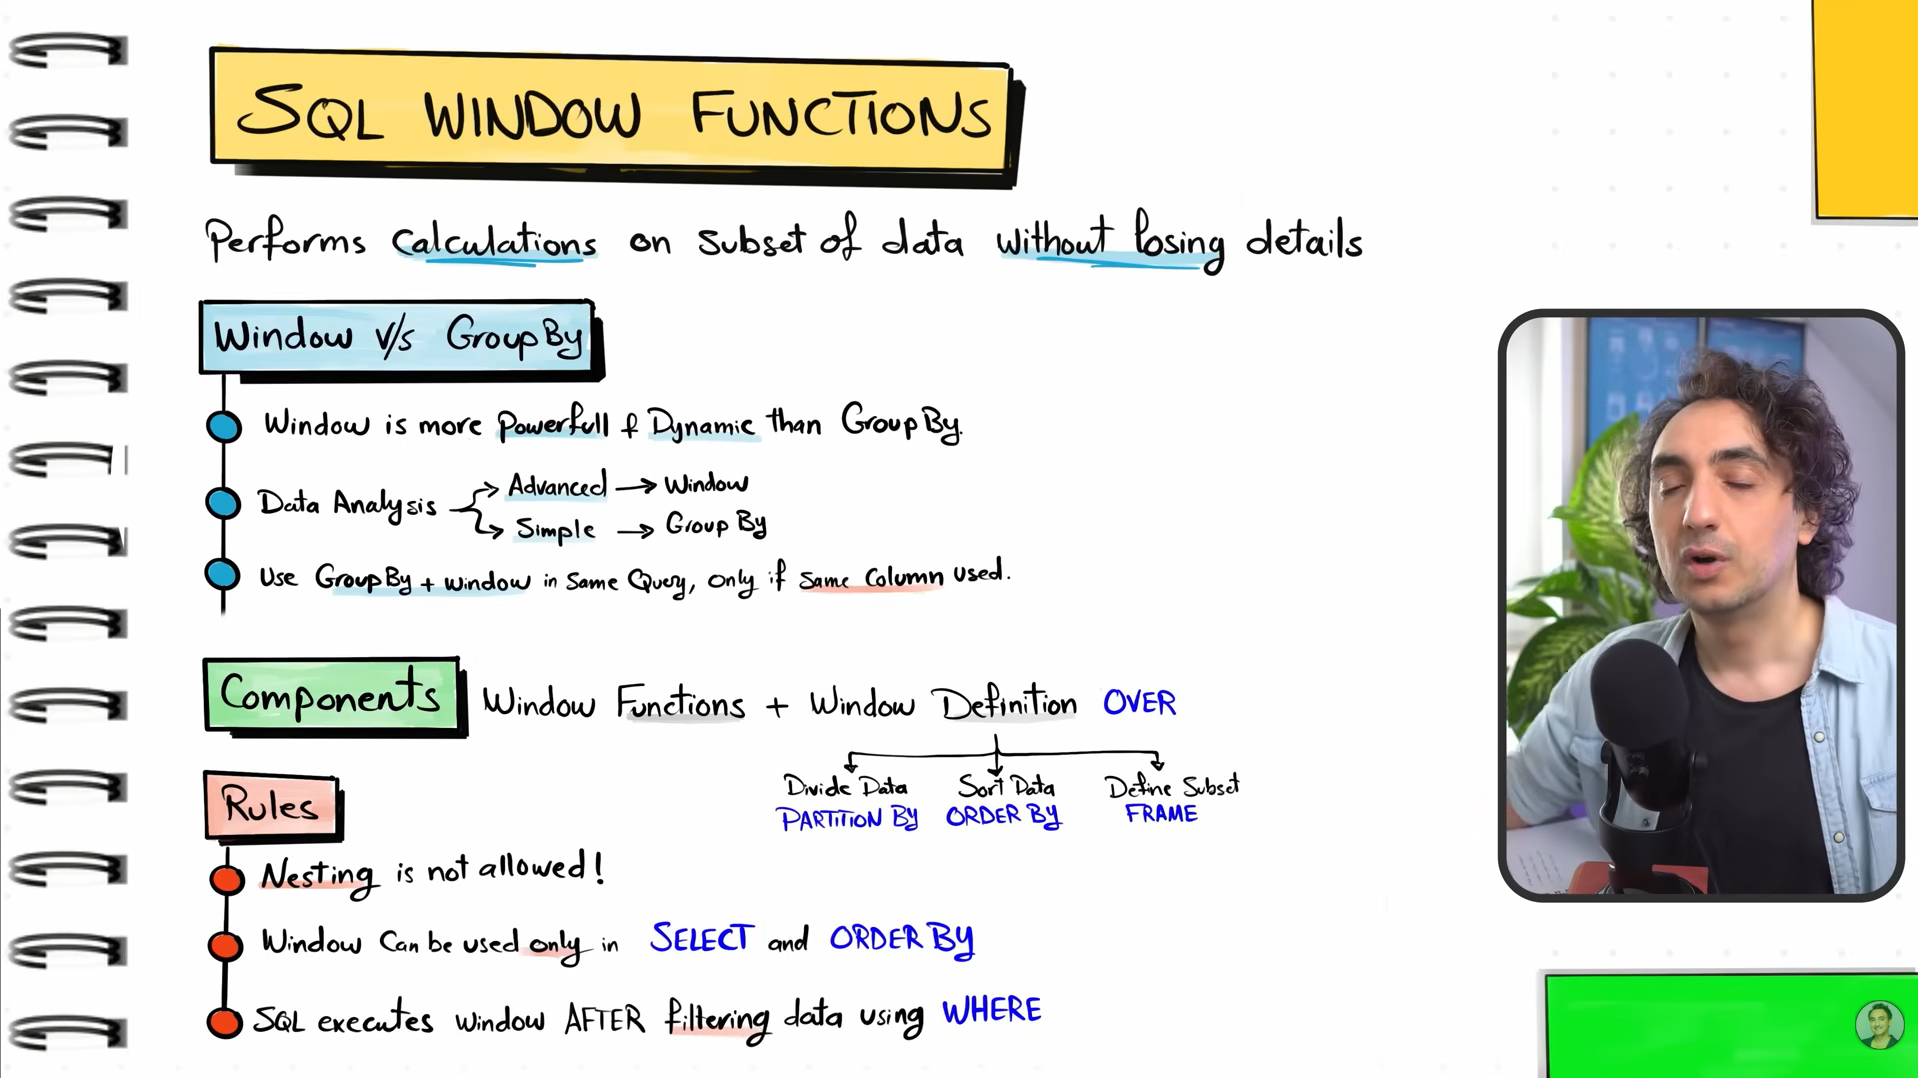

# Window Aggregate Functions : 

## INTRO:

```
SYNTAX :
```
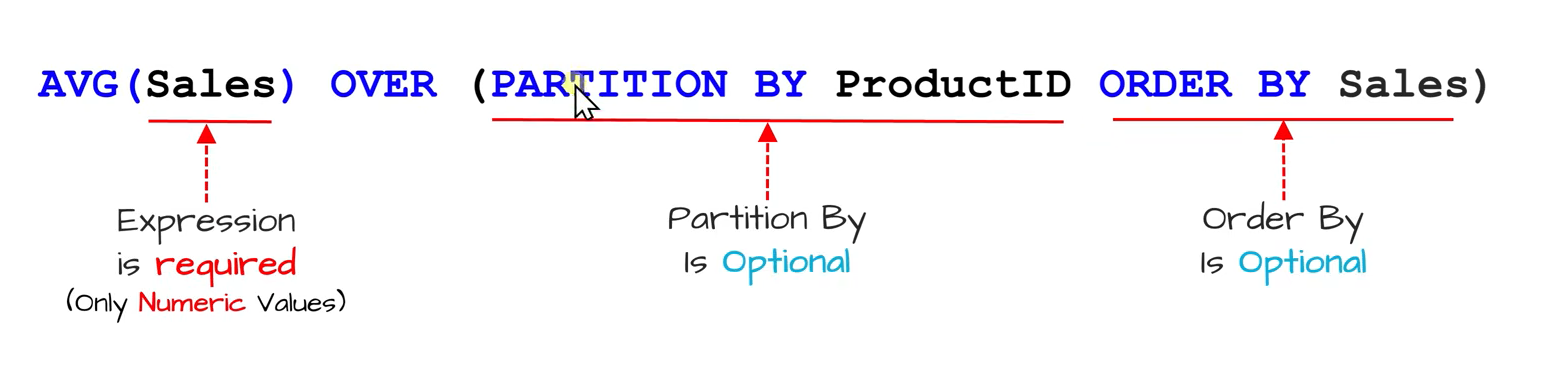

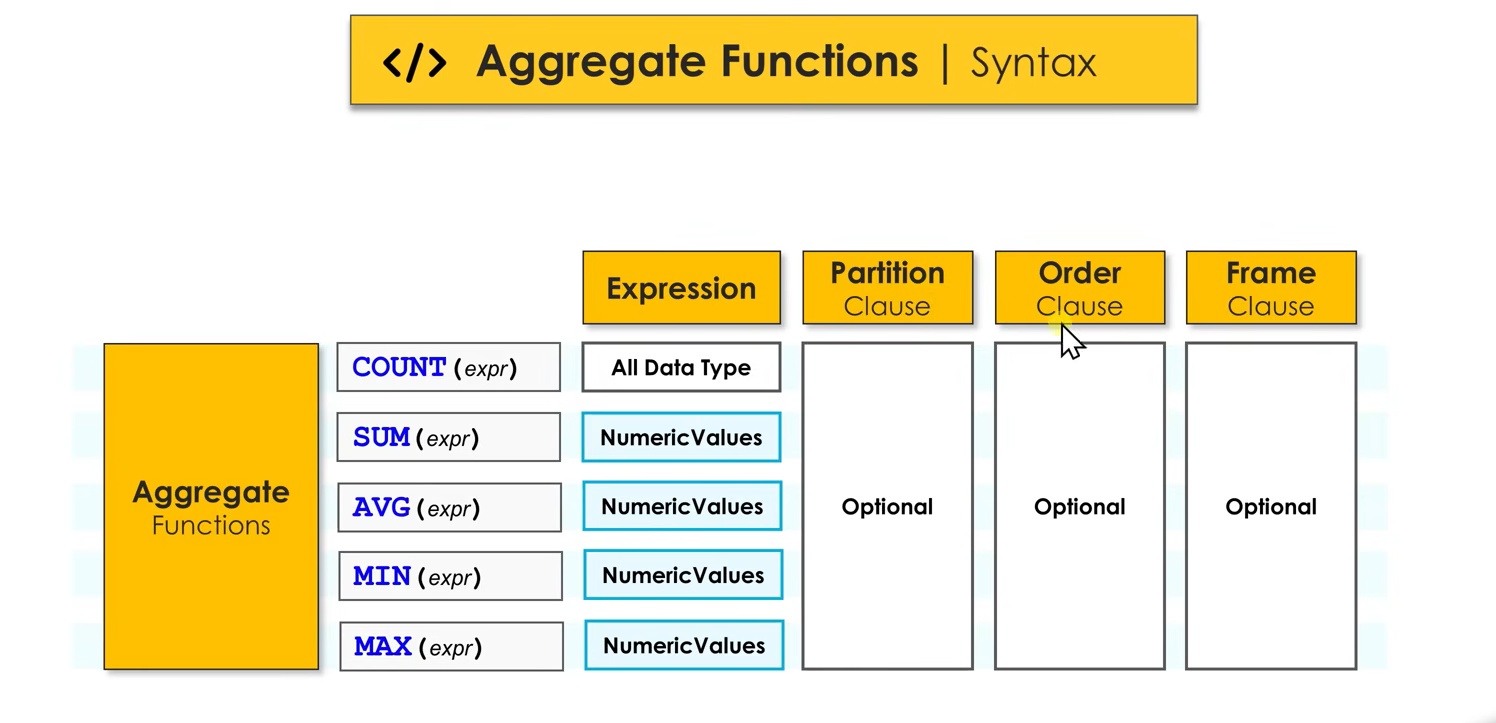

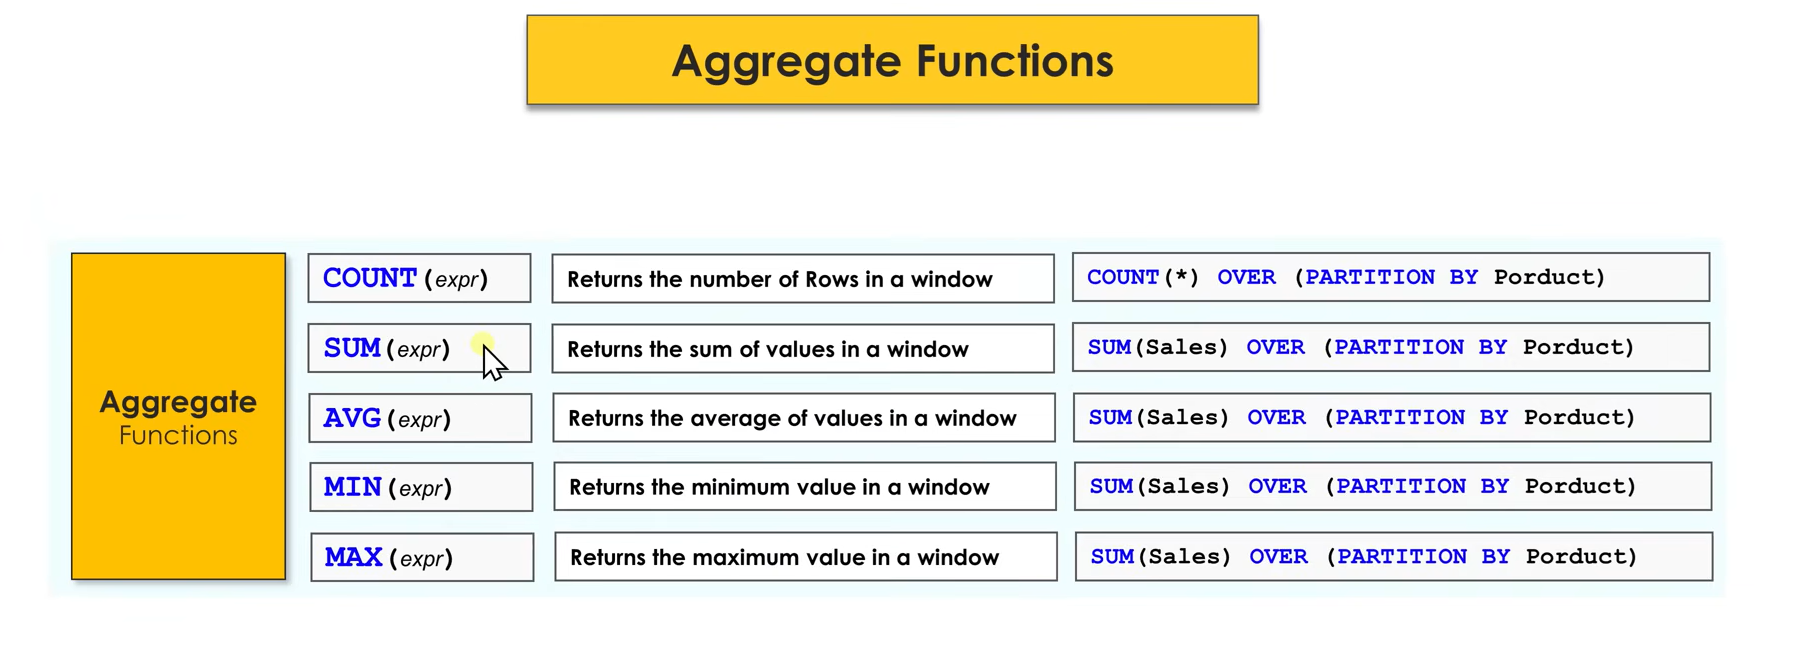

## COUNT(expr(not null)) : Returns the number of rows within each window

### Challenges :

#### Find the number of orders for each product

In [280]:
%%sql
use salesdb;
select p.Product,
    count(sales) as `No. Of Orders`
from orders as o
    left join products as p on p.productid = o.productid
group by p.product;

Running query in 'mysql+pymysql://'

4 rows affected.

Product,No. Of Orders
Bottle,4
Tire,3
Gloves,1
Caps,2


#### Find the total number of orders and also list out the order id and order date

In [284]:
%%sql
select orderid,
    orderdate,
    count(*) over() as `Total Orders`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,Total Orders
1,2025-01-01,10
2,2025-01-05,10
3,2025-01-10,10
4,2025-01-20,10
5,2025-02-01,10
6,2025-02-05,10
7,2025-02-15,10
8,2025-02-18,10
9,2025-03-10,10
10,2025-03-15,10


#### Find the total number of orders by each customers and also list out the order id and order date

In [295]:
%%sql
select o.orderid,
    o.orderdate,
    o.customerid,
    concat_ws(' ', c.firstname, c.lastname) as `Customer Name`,
    count(*) over(partition by c.customerid) as `Total Orders by Each Customers`,
    count(*) over() as `Total Orders`
from orders as o
    left join customers as c on o.customerid = c.customerid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,customerid,Customer Name,Total Orders by Each Customers,Total Orders
3,2025-01-10,1,Jossef Goldberg,3,10
4,2025-01-20,1,Jossef Goldberg,3,10
7,2025-02-15,1,Jossef Goldberg,3,10
1,2025-01-01,2,Kevin Brown,3,10
5,2025-02-01,2,Kevin Brown,3,10
9,2025-03-10,2,Kevin Brown,3,10
2,2025-01-05,3,Mary,3,10
6,2025-02-05,3,Mary,3,10
10,2025-03-15,3,Mary,3,10
8,2025-02-18,4,Mark Schwarz,1,10


#### Find the tota numbers of customers and additionally provide customer's all details

In [297]:
%%sql
select *,
    count(*) over() as `Total Customer's Count`
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score,Total Customer's Count
1,Jossef,Goldberg,Germany,350,5
2,Kevin,Brown,USA,900,5
3,Mary,None,USA,750,5
4,Mark,Schwarz,Germany,500,5
5,Anna,Adams,USA,None,5


#### Find the total number of customers and total numbers of scores for the customers and along with all details of the customers

In [308]:
%%sql
select *,
    count(*) over() as `Customers Count`,
    count(score) over() as `Sales Count`
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score,Customers Count,Sales Count
1,Jossef,Goldberg,Germany,350,5,4
2,Kevin,Brown,USA,900,5,4
3,Mary,None,USA,750,5,4
4,Mark,Schwarz,Germany,500,5,4
5,Anna,Adams,USA,None,5,4


#### Check whether the table Orders contains any duplicates rows

In [318]:
%%sql
select orderid, count(*) over(partition by orderid) as `Check Duplicates` from orders;
-- select orderid, count(*) as `Check PK` from orders group by orderid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,Check Duplicates
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1
10,1


In [12]:
%%sql
use salesdb;
select * from(select orderid, count(*) as `Check PK Count` from orders_archive group by orderid)t where `Check PK Count` > 1;
-- select * from(select orderid, count(*) over(partition by orderid) as `Check` from orders_archive)t where `Check`>1;

Running query in 'mysql+pymysql://'

2 rows affected.

orderid,Check PK Count
4,2
6,3


## SUM(expr) : Returns sum of all values within a window

### Challenges :

#### Find out total sales by each products

In [39]:
%%sql
select o.productid,
    p.product,
    p.category,
    p.price as `MRP`,
    sum(ifnull(o.sales, 0)) as `Total Sales`,
    (sum(ifnull(o.sales, 0)))*p.price as `Total Sale Price`
from orders as o
    left join products as p on o.productid = p.productid
group by o.productid
order by `Total Sale Price` DESC;

Running query in 'mysql+pymysql://'

4 rows affected.

productid,product,category,MRP,Total Sales,Total Sale Price
104,Caps,Clothing,25,75,1875
105,Gloves,Clothing,30,60,1800
102,Tire,Accessories,15,105,1575
101,Bottle,Accessories,10,140,1400


#### Find the TOTAL SALES across all orders, and total sales for each product and provide orderid, productid, orderdate

In [46]:
%%sql
select o.orderid,
    o.productid,
    p.product,
    p.category,
    o.orderdate,
    sum(o.sales) over() as `Total Sales`,
    sales,
    sum(o.sales) over(partition by productid) as `Total Sales By Product`
from orders as o
left join products as p 
on o.productid = p.productid ;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,product,category,orderdate,Total Sales,sales,Total Sales By Product
1,101,Bottle,Accessories,2025-01-01,380,10,140
3,101,Bottle,Accessories,2025-01-10,380,20,140
8,101,Bottle,Accessories,2025-02-18,380,90,140
9,101,Bottle,Accessories,2025-03-10,380,20,140
2,102,Tire,Accessories,2025-01-05,380,15,105
7,102,Tire,Accessories,2025-02-15,380,30,105
10,102,Tire,Accessories,2025-03-15,380,60,105
5,104,Caps,Clothing,2025-02-01,380,25,75
6,104,Caps,Clothing,2025-02-05,380,50,75
4,105,Gloves,Clothing,2025-01-20,380,60,60


##### Comparision UseCase:

##### Compare the current month sales by Year Total Sales, Highest Sale, Lowest Sale, Average Sale by month

In [88]:
%%sql
--- WRONG
select monthname(o.orderdate) as `Month`,
sum(o.sales) over(partition by month(o.orderdate)) as `Monthly Sales`,
sum(o.sales) over() as `Year Sales`,
max(o.sales) over() as `MAX Sale`,
min(o.sales) over() as `MIN Sale`,
round(avg(o.sales) over(), 2) as `AVG Sale`
from orders as o
    left join orders_archive as oa on o.orderid = oa.orderid

UNION

select monthname(oa.orderdate) as `Month`,
sum(oa.sales) over(partition by month(oa.orderdate)) as `Monthly Sales`,
sum(oa.sales) over() as `Year Sales`,
max(oa.sales) over() as `MAX Sale`,
min(oa.sales) over() as `MIN Sale`,
round(avg(oa.sales) over(), 2) as `AVG Sale`
from orders as o
    right join orders_archive as oa on o.orderid = oa.orderid;

Running query in 'mysql+pymysql://'

6 rows affected.

Month,Monthly Sales,Year Sales,MAX Sale,MIN Sale,AVG Sale
January,165,540,90,10,41.54
February,295,540,90,10,41.54
March,80,540,90,10,41.54
April,165,400,60,10,40.00
May,175,400,60,10,40.00
June,60,400,60,10,40.00


In [89]:
%%sql
--- CORRECT
WITH all_orders AS (
    SELECT orderdate, sales FROM orders
    UNION ALL
    SELECT orderdate, sales FROM orders_archive
),
monthly_metrics AS (
    SELECT 
        MONTHNAME(orderdate) AS `Month`,
        MONTH(orderdate) AS `MonthNum`,
        SUM(sales) OVER(PARTITION BY MONTH(orderdate)) AS `Monthly Sales`,
        SUM(sales) OVER() AS `Year Sales`,
        MAX(sales) OVER() AS `MAX Sale`,
        MIN(sales) OVER() AS `MIN Sale`,
        ROUND(AVG(sales) OVER(), 2) AS `AVG Sale`
    FROM all_orders
)
SELECT DISTINCT 
    `Month`, 
    `Monthly Sales`, 
    `Year Sales`, 
    `MAX Sale`, 
    `MIN Sale`, 
    `AVG Sale`
FROM monthly_metrics
ORDER BY FIELD(`Month`, 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December');


Running query in 'mysql+pymysql://'

6 rows affected.

Month,Monthly Sales,Year Sales,MAX Sale,MIN Sale,AVG Sale
January,105,780,90,10,39.00
February,195,780,90,10,39.00
March,80,780,90,10,39.00
April,165,780,90,10,39.00
May,175,780,90,10,39.00
June,60,780,90,10,39.00


#### Find the percentage contribution of each product's sales to the total sales.

In [127]:
%%sql
select
    sales,
    sum(sales) over() as `Total Sales`,
    sum(sales) over(partition by productid) as `Total Sales By Product`,
    productid,
    concat(round(
        sum(sales) over(partition by productid)/sum(sales) over() * 100
    ,2), '%') as `% Contribution By Product`,
    orderid,
    concat(round(
            sales/sum(sales) over() * 100, 2
        ), '%') as `% Contribution By Order`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

sales,Total Sales,Total Sales By Product,productid,% Contribution By Product,orderid,% Contribution By Order
10,380,140,101,36.84%,1,2.63%
20,380,140,101,36.84%,3,5.26%
90,380,140,101,36.84%,8,23.68%
20,380,140,101,36.84%,9,5.26%
15,380,105,102,27.63%,2,3.95%
30,380,105,102,27.63%,7,7.89%
60,380,105,102,27.63%,10,15.79%
25,380,75,104,19.74%,5,6.58%
50,380,75,104,19.74%,6,13.16%
60,380,60,105,15.79%,4,15.79%


## AVG(expr) : Returns the average of values within a window

### Challenges :

#### Find the average sales of each products.

In [137]:
%%sql
select o.orderid,
    o.productid,
    p.product,
    p.category,
    p.price,
    o.sales,
    ROUND(AVG(COALESCE(o.sales,0)) OVER(partition by productid), 2) as `AVG Sales`
from orders as o
    left join products as p on o.productid = p.productid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,product,category,price,sales,AVG Sales
1,101,Bottle,Accessories,10,10,35.00
3,101,Bottle,Accessories,10,20,35.00
8,101,Bottle,Accessories,10,90,35.00
9,101,Bottle,Accessories,10,20,35.00
2,102,Tire,Accessories,15,15,35.00
7,102,Tire,Accessories,15,30,35.00
10,102,Tire,Accessories,15,60,35.00
5,104,Caps,Clothing,25,25,37.50
6,104,Caps,Clothing,25,50,37.50
4,105,Gloves,Clothing,30,60,60.00


### USECASES :

#### 1. Find the average sales across all orders and the average sales for each product. Additionally provide details

In [147]:
%%sql
select o.orderid,
    o.orderdate,
    o.productid,
    p.product,
    o.sales,
    round(avg(coalesce(o.sales, 0)) over(), 2) as `AVG Sales`,
    round(
        avg(coalesce(o.sales, 0)) over(partition by productid),
        2
    ) as `Sales AVG By Product`
from orders as o
    left join products as p on o.productid = p.productid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,product,sales,AVG Sales,Sales AVG By Product
1,2025-01-01,101,Bottle,10,38.00,35.00
3,2025-01-10,101,Bottle,20,38.00,35.00
8,2025-02-18,101,Bottle,90,38.00,35.00
9,2025-03-10,101,Bottle,20,38.00,35.00
2,2025-01-05,102,Tire,15,38.00,35.00
7,2025-02-15,102,Tire,30,38.00,35.00
10,2025-03-15,102,Tire,60,38.00,35.00
5,2025-02-01,104,Caps,25,38.00,37.50
6,2025-02-05,104,Caps,50,38.00,37.50
4,2025-01-20,105,Gloves,60,38.00,60.00


#### 2. Find the average scores of customers and also provide details as customer name and customerid.

In [158]:
%%sql
select customerid,
    concat_ws(' ', firstname, lastname) as `Name`,
    score,
    ROUND(AVG(COALESCE(score, 0)) OVER(), 2) as `AVG Scores`
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,Name,score,AVG Scores
1,Jossef Goldberg,350,500.00
2,Kevin Brown,900,500.00
3,Mary,750,500.00
4,Mark Schwarz,500,500.00
5,Anna Adams,None,500.00


#### 3. Find all orders where sales are higher than the average sales across all orders.

In [172]:
%%sql
select *
from (
        select orderid,
            orderdate,
            sales,
            ROUND(AVG(COALESCE(sales, 0)) OVER(), 2) as `AVG Sales`
        from orders
    )t
where `AVG Sales` < sales;

Running query in 'mysql+pymysql://'

4 rows affected.

orderid,orderdate,sales,AVG Sales
4,2025-01-20,60,38.00
6,2025-02-05,50,38.00
8,2025-02-18,90,38.00
10,2025-03-15,60,38.00


## MIN() - MAX()
### MIN() : Returns the lowest value within a window
### MAX() : Returns the highest value within a window

#### Challenges or USECASES :

##### 1. Find the lowest and highest sales for each product.

In [180]:
%%sql
select o.orderid,
    o.orderdate,
    o.productid,
    p.product,
    o.sales,
    min(coalesce(o.sales, 0)) over() as `Lowest Sale`,
    max(coalesce(o.sales, 0)) over() as `Highest Sale`,
    min(coalesce(o.sales,0)) over(partition by o.productid) as `Lowest Sale By Product`,
    max(coalesce(o.sales, 0)) over(partition by o.productid) as `Highest Sale By Product`
from orders as o
    left join products as p on o.productid = p.productid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,product,sales,Lowest Sale,Highest Sale,Lowest Sale By Product,Highest Sale By Product
1,2025-01-01,101,Bottle,10,10,90,10,90
3,2025-01-10,101,Bottle,20,10,90,10,90
8,2025-02-18,101,Bottle,90,10,90,10,90
9,2025-03-10,101,Bottle,20,10,90,10,90
2,2025-01-05,102,Tire,15,10,90,15,60
7,2025-02-15,102,Tire,30,10,90,15,60
10,2025-03-15,102,Tire,60,10,90,15,60
5,2025-02-01,104,Caps,25,10,90,25,50
6,2025-02-05,104,Caps,50,10,90,25,50
4,2025-01-20,105,Gloves,60,10,90,60,60


##### 2. Show the employees who have highest salaries.

In [188]:
%%sql
select *
from(
        select *,
            max(salary) over() as `Highest Salary`
        from employees
    ) t
where salary = `Highest Salary`;

Running query in 'mysql+pymysql://'

1 rows affected.

employeeid,firstname,lastname,department,birthdate,gender,salary,managerid,Highest Salary
4,Michael,Ray,Sales,1977-02-10,M,90000,2,90000


##### 3. Find the deviation of each sales from both minimum and maximum sales amount.

In [221]:
%%sql
select orderid,
    productid,
    sales,
    min(sales) over() as `Min Sale`,
    max(sales) over() as `Max Sale`,
    sales - min(sales) over() as `Deviation Form Min`,
    max(sales) OVER() - sales as `Deviation From Max`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,sales,Min Sale,Max Sale,Deviation Form Min,Deviation From Max
1,101,10,10,90,0,80
2,102,15,10,90,5,75
3,101,20,10,90,10,70
4,105,60,10,90,50,30
5,104,25,10,90,15,65
6,104,50,10,90,40,40
7,102,30,10,90,20,60
8,101,90,10,90,80,0
9,101,20,10,90,10,70
10,102,60,10,90,50,30


### 4. RUNNING TOTAL & ROLLING TOTAL
```
Used for:
    1. Tracking : Current sales with Target sales
    2. Trend Analysis : Providing Insights into historical patterns
```

##### Running Total : 
```
1. Aggregate all value from the beginning upto current point without dropping off older data.
```

##### Rolling Total :
```
1. Aggregate all values within a fixed time window (e.g. 30 days).
2. As new data is added, the oldest data point will be dropped.
3. aka(Rolling or Shifting Window)
```

### Challenges / USECASES :

#### 1. Find the Running Total and 2 Months Rolling Total of sales by month

In [270]:
%%sql
with RT as(
    select distinct month(orderdate) as `Month_Num`,
        monthname(orderdate) as `Month`,
        sum(sales) over(partition by month(orderdate)) as Total_Sales
    from orders
)
select Month,
    Total_Sales,
    sum(Total_Sales) over(
        order by Month_Num
    ) as `Running Total`,
    sum(Total_Sales) over(
        order by Month_Num rows between 1 preceding and current row
    ) as `Rolling Total`
from RT;

Running query in 'mysql+pymysql://'

3 rows affected.

Month,Total_Sales,Running Total,Rolling Total
January,105,105,105
February,195,300,300
March,80,380,275


#### 2. MOVING AVERAGE : Calculate the moving average of sales for each product over time

In [351]:
%%sql
select o.orderid,
o.productid,
p.product,
o.orderdate,
o.sales,
-- Normal
sum(coalesce(o.sales, 0)) over(partition by o.productid) as `Total_Sales`,
ROUND(AVG(coalesce(o.sales, 0)) over(partition by o.productid), 1) as `AVG_Sales`,
-- Running
sum(coalesce(o.sales, 0)) over(partition by o.productid order by o.orderdate) as `Running_Total`,
round(avg(coalesce(o.sales, 0)) over(partition by o.productid order by o.orderdate), 1) as `Running_AVG`,
-- ROlling by Month
sum(coalesce(o.sales, 0)) over(partition by o.productid, month(o.orderdate) order by o.orderdate range between interval 1 month preceding and current row) as `Rolling_Total`,
round(avg(coalesce(o.sales, 0)) over(partition by o.productid, month(o.orderdate) order by o.orderdate range between interval 1 month preceding and current row), 1) as `Rolling_AVG`,
-- Rolling By current and next order
sum(coalesce(o.sales, 0)) over(partition by o.productid order by o.orderdate rows between current row and 1 following) as `Rolling_Total_Next`,
round(avg(coalesce(o.sales, 0)) over(partition by o.productid order by o.orderdate rows between current row and 1 following), 1) as `Rolling_AVG_Next`

from orders as o
left join products as p
on o.productid=p.productid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,product,orderdate,sales,Total_Sales,AVG_Sales,Running_Total,Running_AVG,Rolling_Total,Rolling_AVG,Rolling_Total_Next,Rolling_AVG_Next
1,101,Bottle,2025-01-01,10,140,35.0,10,10.0,10,10.0,30,15.0
3,101,Bottle,2025-01-10,20,140,35.0,30,15.0,30,15.0,110,55.0
8,101,Bottle,2025-02-18,90,140,35.0,120,40.0,90,90.0,110,55.0
9,101,Bottle,2025-03-10,20,140,35.0,140,35.0,20,20.0,20,20.0
2,102,Tire,2025-01-05,15,105,35.0,15,15.0,15,15.0,45,22.5
7,102,Tire,2025-02-15,30,105,35.0,45,22.5,30,30.0,90,45.0
10,102,Tire,2025-03-15,60,105,35.0,105,35.0,60,60.0,60,60.0
5,104,Caps,2025-02-01,25,75,37.5,25,25.0,25,25.0,75,37.5
6,104,Caps,2025-02-05,50,75,37.5,75,37.5,75,37.5,50,50.0
4,105,Gloves,2025-01-20,60,60,60.0,60,60.0,60,60.0,60,60.0


#### SUMMARY :

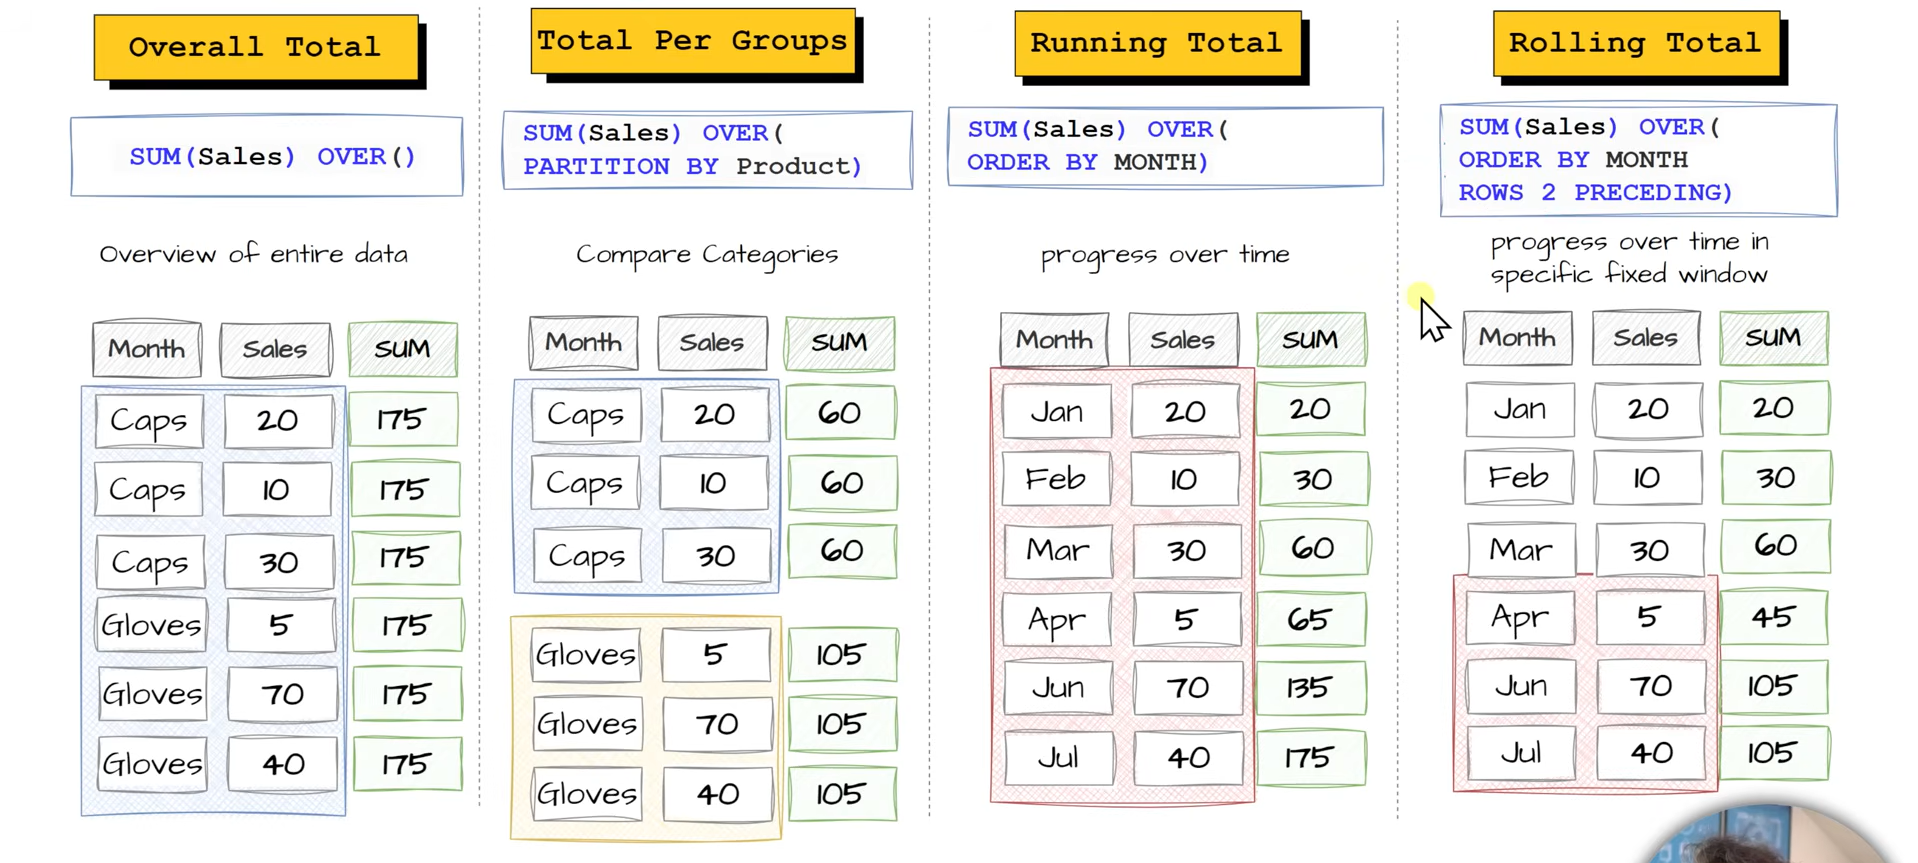

# Window Ranking Function : 

# Window Value Function : 

# Extra:

In [316]:
%%sql
use salesdb;

Running query in 'mysql+pymysql://'

++
||
++
++